**PASO 1: Carga del conjunto de datos**

In [18]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import joblib
import warnings
warnings.filterwarnings("ignore")

In [19]:
# CARGO LOS DATOS
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
df = pd.read_csv(url)

In [20]:
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Filas: 20640 | Columnas: 9


In [21]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [22]:
print("\nEstadísticas descriptivas:")
df.describe()


Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [23]:
print(f"\nValores nulos:\n{df.isnull().sum()}")


Valores nulos:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


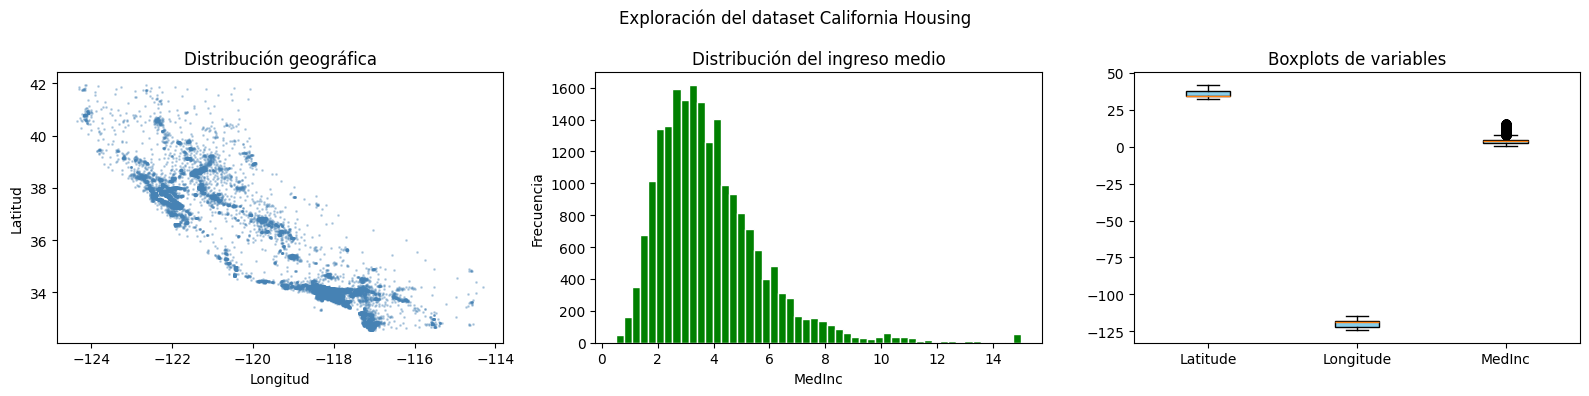

In [24]:
# GRAFICAR
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Exploración del dataset California Housing")

axes[0].scatter(df["Longitude"], df["Latitude"], s=1, alpha=0.3, color="steelblue")
axes[0].set_title("Distribución geográfica")
axes[0].set_xlabel("Longitud"); axes[0].set_ylabel("Latitud")

axes[1].hist(df["MedInc"], bins=50, color="green", edgecolor="white")
axes[1].set_title("Distribución del ingreso medio")
axes[1].set_xlabel("MedInc"); axes[1].set_ylabel("Frecuencia")

axes[2].boxplot(df[["Latitude", "Longitude", "MedInc"]].values,
                labels=["Latitude", "Longitude", "MedInc"],
                patch_artist=True,
                boxprops=dict(facecolor="skyblue"))
axes[2].set_title("Boxplots de variables")

plt.tight_layout()
plt.show()

In [25]:
# Separo en train y test
X = df.copy()
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
print(f"\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")


Train: 16512 muestras | Test: 4128 muestras


In [26]:
# Escalado (K-Means es sensible a la escala)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**PASO 2: Entrenamiento del K-Means (k=6)**

In [27]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10, max_iter=300)
kmeans.fit(X_train_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [28]:
# Asigno etiquetas al conjunto de train
X_train = X_train.copy()
X_train["cluster"] = kmeans.labels_.astype(str)

print("Distribución de clusters (train):")
print(X_train["cluster"].value_counts().sort_index())

Distribución de clusters (train):
cluster
0     973
1      65
2    7083
3    5908
4    2482
5       1
Name: count, dtype: int64


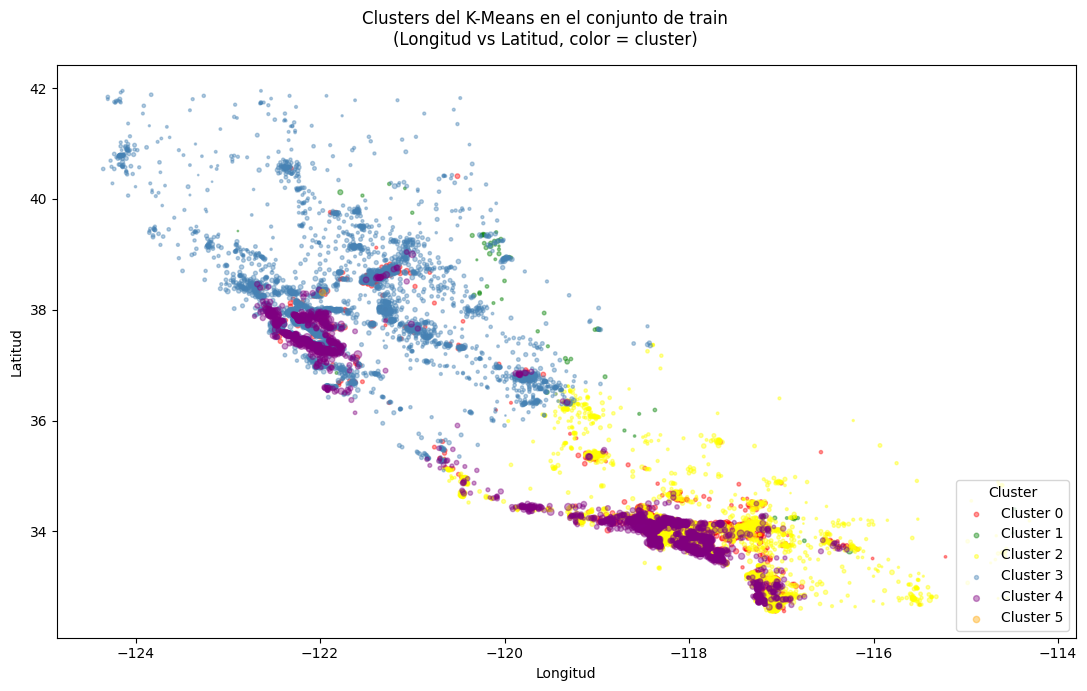

In [29]:
# Gráfico de dispersión — Train coloreado por cluster
colors = ["red", "green", "yellow", "steelblue", "purple", "orange"]

fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle("Clusters del K-Means en el conjunto de train\n"
             "(Longitud vs Latitud, color = cluster)")

for i, cl in enumerate(sorted(X_train["cluster"].unique())):
    mask = X_train["cluster"] == cl
    ax.scatter(
        X_train.loc[mask, "Longitude"],
        X_train.loc[mask, "Latitude"],
        s=X_train.loc[mask, "MedInc"] * 2,
        alpha=0.4, color=colors[int(cl)], label=f"Cluster {cl}"
    )

ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(title="Cluster", loc="lower right")
plt.tight_layout()
plt.show()

**Observaciones**
- Las seis regiones geográficas en California están claramente delimitadas en el gráfico.
- Los clusters con mayor ingreso (MedInc alto) tienden a concentrarse en zonas costeras (Los Ángeles, San Diego, el área de la Bahía de San Francisco).
- Los clusters del interior (Valle Central de California) presentan ingresos más bajos.
- El tamaño de los puntos refuerza visualmente esta separación.

**PASO 3: Predicción con el conjunto de test**

In [30]:
X_test = X_test.copy()
X_test["cluster"] = kmeans.predict(X_test_scaled).astype(str)

print("Distribución de clusters (test):")
print(X_test["cluster"].value_counts().sort_index())

Distribución de clusters (test):
cluster
0     249
1      15
2    1821
3    1459
4     584
Name: count, dtype: int64


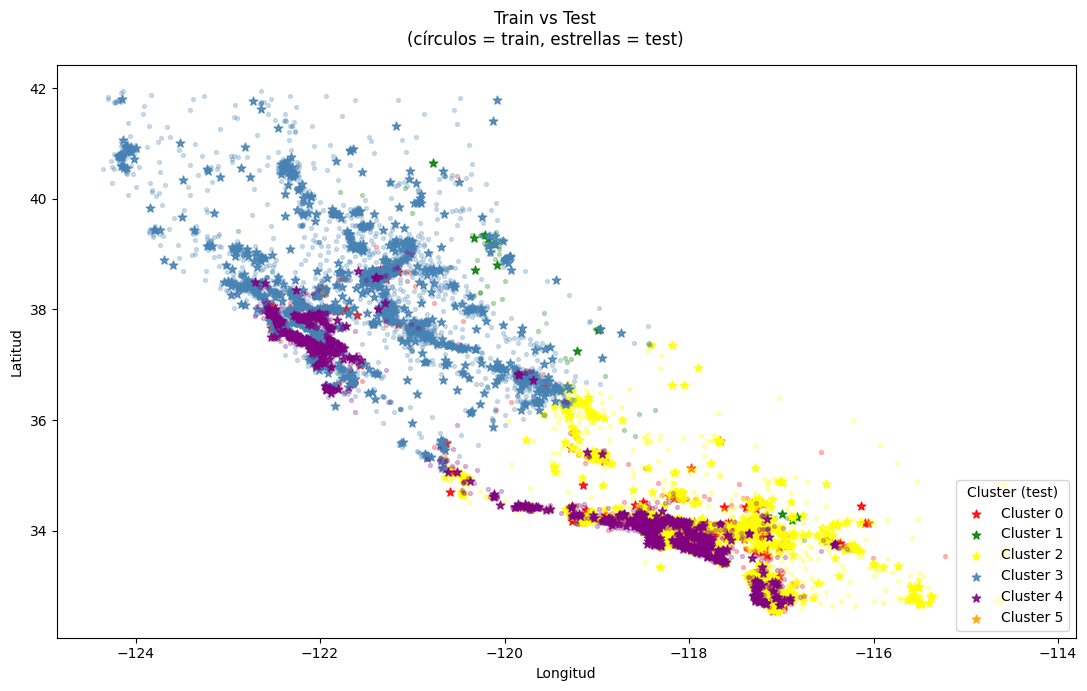

In [31]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.suptitle("Train vs Test\n"
             "(círculos = train, estrellas = test)")

for i, cl in enumerate(sorted(X_train["cluster"].unique())):
    mask_tr = X_train["cluster"] == cl
    mask_te = X_test["cluster"] == cl
    ax.scatter(X_train.loc[mask_tr, "Longitude"], X_train.loc[mask_tr, "Latitude"],
               s=8, alpha=0.25, color=colors[int(cl)])
    ax.scatter(X_test.loc[mask_te, "Longitude"], X_test.loc[mask_te, "Latitude"],
               s=40, alpha=0.85, color=colors[int(cl)], marker="*",
               label=f"Cluster {cl}")

ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.legend(title="Cluster (test)", loc="lower right")
plt.tight_layout()
plt.show()

**Observaciones**
- Las estrellas (test) siguen exactamente los mismos patrones geográficos que los círculos (train), así que la predicción es satisfactoria.
- No se aprecian puntos fuera de lugar, lo que confirma que el modelo generaliza bien.

**PASO 4: Modelo supervisado (Random Forest)**

In [32]:
feature_cols = ["Latitude", "Longitude", "MedInc"]
y_train = X_train["cluster"].astype(int)
y_test = X_test["cluster"].astype(int)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy en test: {accuracy} ({accuracy*100:.2f} %)\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=[f"Cluster {i}" for i in range(5)]))

Accuracy en test: 0.9876453488372093 (98.76 %)

Classification report:
              precision    recall  f1-score   support

   Cluster 0       0.97      0.94      0.95       249
   Cluster 1       1.00      1.00      1.00        15
   Cluster 2       0.99      0.99      0.99      1821
   Cluster 3       0.99      0.99      0.99      1459
   Cluster 4       0.98      0.98      0.98       584

    accuracy                           0.99      4128
   macro avg       0.99      0.98      0.98      4128
weighted avg       0.99      0.99      0.99      4128



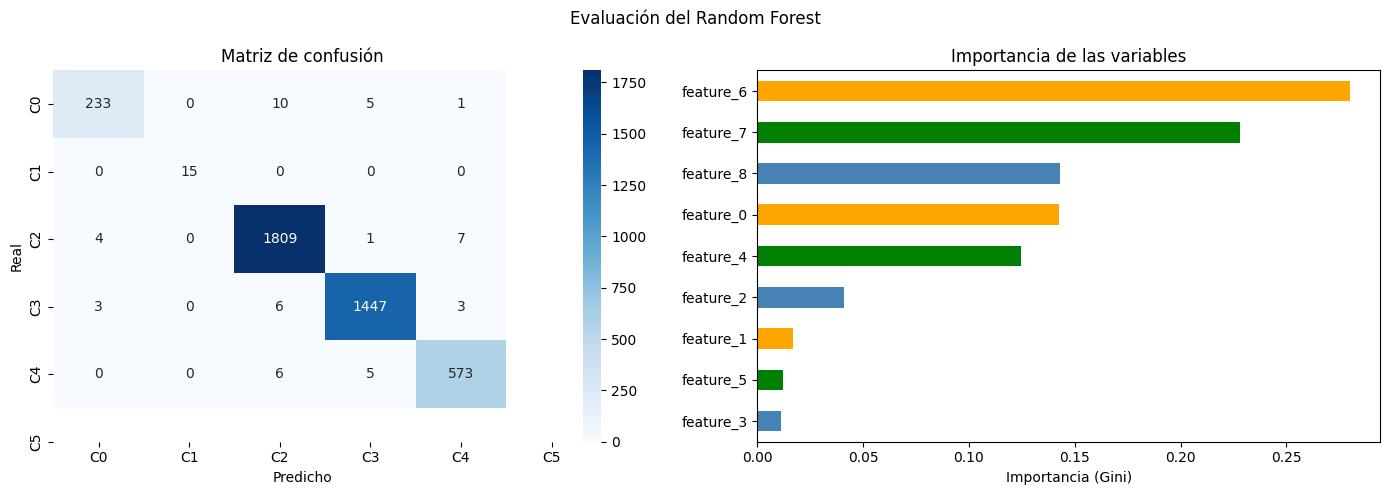

In [33]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluación del Random Forest")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[f"C{i}" for i in range(6)],
            yticklabels=[f"C{i}" for i in range(6)], ax=axes[0])
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

# Importancia de las variables
feature_names = [f"feature_{i}" for i in range(len(rf.feature_importances_))]
feat_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values()
feat_imp.plot(kind="barh", color=["steelblue", "green", "orange"], ax=axes[1])
axes[1].set_title("Importancia de las variables")
axes[1].set_xlabel("Importancia (Gini)")

plt.tight_layout()
plt.show()

**Observaciones**
- Se eligió Random Forest porque maneja bien múltiples clases sin necesidad de mucho ajuste, es robusto frente a la escala y da la importancia de las variables de forma directa.
- Como el **accuracy en test = 98.76 %**, el modelo aprende muy bien los límites de cada región definida por el K-Means.
- La importancia de las variables muestra que la latitud y la longitud dominan la clasificación (datos geoespaciales), mientras que MedInc ayuda a separar los clusters que se solapan geográficamente.
- La matriz de confusión confirma que casi todos los clusters se predicen sin ambigüedad porque hay muy pocos errores fuera de la diagonal.

**PASO 5: Guardar los modelos**

In [34]:
os.makedirs("../models", exist_ok=True)
joblib.dump(kmeans, "../models/kmeans_california.pkl")
joblib.dump(rf,     "../models/random_forest_california.pkl")
joblib.dump(scaler, "../models/scaler_california.pkl")

print("Modelos guardados en /models/:")
print("  - kmeans_california.pkl")
print("  - random_forest_california.pkl")
print("  - scaler_california.pkl")

Modelos guardados en /models/:
  - kmeans_california.pkl
  - random_forest_california.pkl
  - scaler_california.pkl
